In [1]:
from google.colab import files

uploaded = files.upload()


Saving fraudTest.csv to fraudTest.csv


In [2]:
import os

print(os.listdir())

['.config', 'fraudTest.csv', 'sample_data']


In [3]:
import pandas as pd

df = pd.read_csv('fraudTest.csv')   # change filename if needed

print(df.shape)
df.head()

(555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [4]:
df.columns.tolist()

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud']

In [5]:
print(type(df))
print(df.head())

<class 'pandas.core.frame.DataFrame'>
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2020-06-21 12:14:25  2291163933867244   
1           1   2020-06-21 12:14:33  3573030041201292   
2           2   2020-06-21 12:14:53  3598215285024754   
3           3   2020-06-21 12:15:15  3591919803438423   
4           4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashley   
3                     fraud_Haley Group        misc_pos  60.05   Brian   
4                 fraud_Johnston-Casper          travel   3.19  Nathan   

       last gender                       street  ...      lat      long  \
0   Elliott      M            351 Darlene Green  ...  33.9659  -80.9355   
1  Williams      F      

In [6]:
df.shape

(555719, 23)

In [7]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,553574
1,2145


In [8]:
fraud = df[df['is_fraud'] == 1]

not_fraud = df[df['is_fraud'] == 0].sample(
    n=7855,
    random_state=42
)

df_small = pd.concat([fraud, not_fraud])

# Shuffle rows
df_small = df_small.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(df_small['is_fraud'].value_counts())
print(df_small.shape)

is_fraud
0    7855
1    2145
Name: count, dtype: int64
(10000, 23)


In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [10]:
for col in df.columns:
    print(col, df[col].nunique())

Unnamed: 0 555719
trans_date_trans_time 544760
cc_num 924
merchant 693
category 14
amt 37256
first 341
last 471
gender 2
street 924
city 849
state 50
zip 912
lat 910
long 910
city_pop 835
job 478
dob 910
trans_num 555719
unix_time 544760
merch_lat 546490
merch_long 551770
is_fraud 2


In [12]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

In [14]:
from sklearn.ensemble import RandomForestClassifier

X = df_model.drop('is_fraud', axis=1)
y = df_model['is_fraud']

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [15]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)


                  Feature  Importance
5                     amt    0.304132
4                category    0.111473
1   trans_date_trans_time    0.057412
19              unix_time    0.056648
0              Unnamed: 0    0.056538
21             merch_long    0.038629
20              merch_lat    0.037908
17                    dob    0.030850
18              trans_num    0.030689
3                merchant    0.029823
15               city_pop    0.028179
16                    job    0.023953
2                  cc_num    0.023211
9                  street    0.022251
7                    last    0.022145
10                   city    0.021790
12                    zip    0.021626
6                   first    0.021532
13                    lat    0.020193
14                   long    0.018856
11                  state    0.015243
8                  gender    0.006920


In [17]:
remove_cols = [
    'Unnamed: 0',
    'trans_num',
    'first',
    'last',
    'street'
]

In [18]:
df = df.drop(columns=[
    'Unnamed: 0',
    'trans_num',
    'first',
    'last',
    'street'
])

In [19]:
import pandas as pd

df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time']
)

In [20]:
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['weekday'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month
df['year'] = df['trans_date_trans_time'].dt.year


In [21]:
df['dob'] = pd.to_datetime(df['dob'])

df['age'] = (
    df['trans_date_trans_time'] - df['dob']
).dt.days // 365

In [22]:
df.drop(columns=['dob'], inplace=True)

In [23]:
import numpy as np

df['distance'] = np.sqrt(
    (df['lat'] - df['merch_lat'])**2 +
    (df['long'] - df['merch_long'])**2
)

In [24]:
df.drop(columns=['trans_date_trans_time'], inplace=True)

In [25]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'merchant',
    'category',
    'gender',
    'city',
    'state',
    'job'
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [26]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'merchant',
    'category',
    'gender',
    'city',
    'state',
    'job'
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [27]:
fraud = df[df['is_fraud'] == 1]

not_fraud = df[df['is_fraud'] == 0].sample(
    n=7855,
    random_state=42
)

df_balanced = pd.concat([fraud, not_fraud])

df_balanced = df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [28]:
print(df_balanced.shape)

print(df_balanced['is_fraud'].value_counts())

(10000, 23)
is_fraud
0    7855
1    2145
Name: count, dtype: int64


In [29]:
from sklearn.preprocessing import StandardScaler

X = df_balanced.drop('is_fraud', axis=1)
y = df_balanced['is_fraud']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1571
           1       0.95      0.85      0.90       429

    accuracy                           0.96      2000
   macro avg       0.96      0.92      0.94      2000
weighted avg       0.96      0.96      0.96      2000



In [32]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, preds))

[[1552   19]
 [  63  366]]


In [33]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

,Feature,Importance
3,amt,0.481074
15,hour,0.144217
2,category,0.045957
12,unix_time,0.032498
10,city_pop,0.022848
20,age,0.021924
11,job,0.021864
5,city,0.021592
0,cc_num,0.019459
16,day,0.019356


In [34]:
import joblib

joblib.dump(rf, 'fraud_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [35]:
['unix_time']

['unix_time']

In [36]:
distance

NameError: name 'distance' is not defined

In [37]:
print(df.columns.tolist())

['cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'hour', 'day', 'weekday', 'month', 'year', 'age', 'distance']


In [38]:
feature_importance.sort_values(
    'Importance',
    ascending=False
)

,Feature,Importance
3,amt,0.481074
15,hour,0.144217
2,category,0.045957
12,unix_time,0.032498
10,city_pop,0.022848
20,age,0.021924
11,job,0.021864
5,city,0.021592
0,cc_num,0.019459
16,day,0.019356


In [39]:
probs = rf.predict_proba(X_test)[:,1]

preds_40 = (probs > 0.40).astype(int)

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds_40))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1571
           1       0.92      0.91      0.91       429

    accuracy                           0.96      2000
   macro avg       0.95      0.94      0.95      2000
weighted avg       0.96      0.96      0.96      2000



In [41]:
import joblib

joblib.dump(rf, 'fraud_rf_model_final.pkl')
joblib.dump(scaler, 'fraud_scaler_final.pkl')

['fraud_scaler_final.pkl']

In [42]:
df_balanced.to_csv(
    'fraud_10000_engineered.csv',
    index=False
)

In [43]:
from sklearn.metrics import roc_auc_score

probs = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, probs)

print("ROC-AUC:", auc)

ROC-AUC: 0.9922881065465406


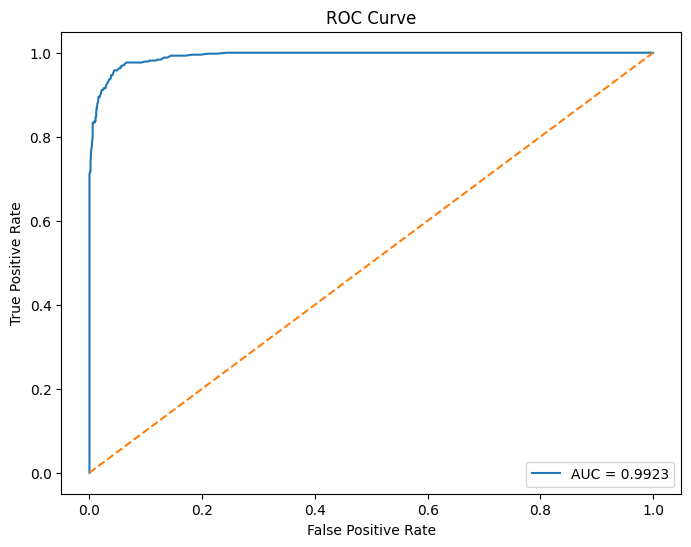

In [44]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [45]:
import joblib

joblib.dump(rf, 'fraud_rf_model_final.pkl')
joblib.dump(scaler, 'fraud_scaler_final.pkl')

print("Model and scaler saved.")

Model and scaler saved.


In [46]:
import os

print(os.listdir())


['.config', 'fraud_scaler_final.pkl', 'fraudTest.csv', 'fraud_rf_model.pkl', 'fraud_rf_model_final.pkl', 'fraud_10000_engineered.csv', 'scaler.pkl', 'sample_data']


In [47]:
from google.colab import files

files.download('fraud_rf_model_final.pkl')
files.download('fraud_scaler_final.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
rf_loaded = joblib.load('fraud_rf_model_final.pkl')
scaler_loaded = joblib.load('fraud_scaler_final.pkl')

print(type(rf_loaded))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [49]:
import joblib

joblib.dump(rf, 'fraud_rf_model_final.pkl')
joblib.dump(scaler, 'fraud_scaler_final.pkl')

print("Saved successfully!")

Saved successfully!


In [50]:
import os

print([f for f in os.listdir() if f.endswith('.pkl')])

['fraud_scaler_final.pkl', 'fraud_rf_model.pkl', 'fraud_rf_model_final.pkl', 'scaler.pkl']


In [51]:
from google.colab import files

files.download('fraud_rf_model_final.pkl')
files.download('fraud_scaler_final.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
print(df_balanced['is_fraud'].value_counts())

print(
    df_balanced['is_fraud'].value_counts(normalize=True) * 100
)

is_fraud
0    7855
1    2145
Name: count, dtype: int64
is_fraud
0    78.55
1    21.45
Name: proportion, dtype: float64
